Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Question 1 — Statistics with Titanic Data

Task 1 — Load and Prepare Data

In [ ]:
data = pd.read_csv("/content/Taitanic.csv")

In [ ]:
df = pd.DataFrame({
    'survived': data['Survived'],
    'sex': data['Sex'],
    'age': data['Age'],
    'fare': data['Fare'],
    'pclass': data['Pclass']
})

In [ ]:
df

,survived,sex,age,fare,pclass
0,0,male,22.0,7.2500,3
1,1,female,38.0,71.2833,1
2,1,female,26.0,7.9250,3
3,1,female,35.0,53.1000,1
4,0,male,35.0,8.0500,3
...,...,...,...,...,...
886,0,male,27.0,13.0000,2
887,1,female,19.0,30.0000,1
888,0,female,NaN,23.4500,3
889,1,male,26.0,30.0000,1


In [ ]:
df = df.dropna()

In [ ]:
df.shape

(714, 5)

In [ ]:
df.head()

,survived,sex,age,fare,pclass
0,0,male,22.0,7.2500,3
1,1,female,38.0,71.2833,1
2,1,female,26.0,7.9250,3
3,1,female,35.0,53.1000,1
4,0,male,35.0,8.0500,3


Task 2 — Central Tendency

In [ ]:
age_mean = df['age'].mean()
age_median = df['age'].median()
age_mode = df['age'].mode()

print(age_mean)
print(age_median)
print(age_mode)

29.69911764705882
28.0
0    24.0
Name: age, dtype: float64


In [ ]:
fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode()

print(fare_mean)
print(fare_median)
print(fare_mode)

34.694514005602244
15.7417
0    13.0
Name: fare, dtype: float64


Task 3 — Measures of Dispersion

In [ ]:
age_var = df['age'].var()
age_std = df['age'].std()
age_range = df['age'].max() - df['age'].min()

print(age_var)
print(age_std)
print(age_range)

211.0191247463081
14.526497332334044
79.58


In [ ]:
fare_var = df['fare'].var()
fare_std = df['fare'].std()
fare_range = df['fare'].max() - df['fare'].min()

print(fare_var)
print(fare_std)
print(fare_range)

2800.413099695179
52.9189295025436
512.3292


Task 4 — Correlation Analysis

In [ ]:
corr = df[['survived', 'age', 'fare', 'pclass']].corr()

corr

,survived,age,fare,pclass
survived,1.000000,-0.077221,0.268189,-0.359653
age,-0.077221,1.000000,0.096067,-0.369226
fare,0.268189,0.096067,1.000000,-0.554182
pclass,-0.359653,-0.369226,-0.554182,1.000000


#Question 2 — Data Visualization

Task 2 — Survival Report

In [ ]:
surv_by_class = df.groupby('pclass')['survived'].sum()
surv_by_class

,survived
pclass,
1,122
2,83
3,85


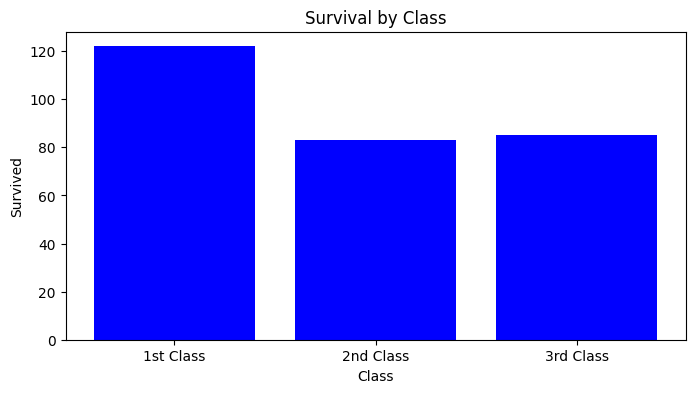

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(['1st Class', '2nd Class', '3rd Class'], surv_by_class.values, color='blue')
plt.xlabel('Class')
plt.ylabel('Survived')
plt.title('Survival by Class')
plt.show()

In [ ]:
surv_by_sex = df.groupby('sex')['survived'].sum()
surv_by_sex

,survived
sex,
female,197
male,93


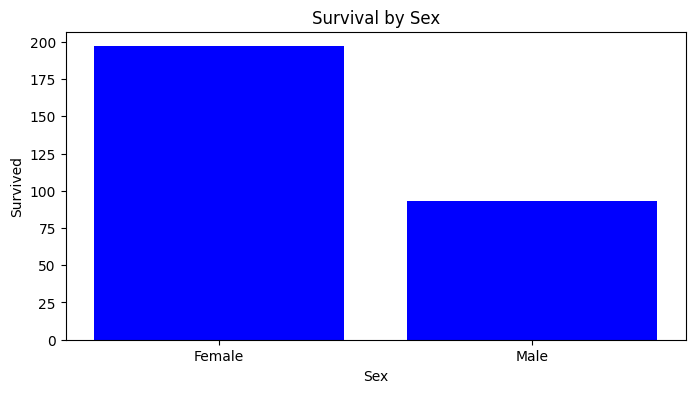

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(['Female', 'Male'], surv_by_sex.values, color='blue')
plt.xlabel('Sex')
plt.ylabel('Survived')
plt.title('Survival by Sex')
plt.show()

Task 3 — Age Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

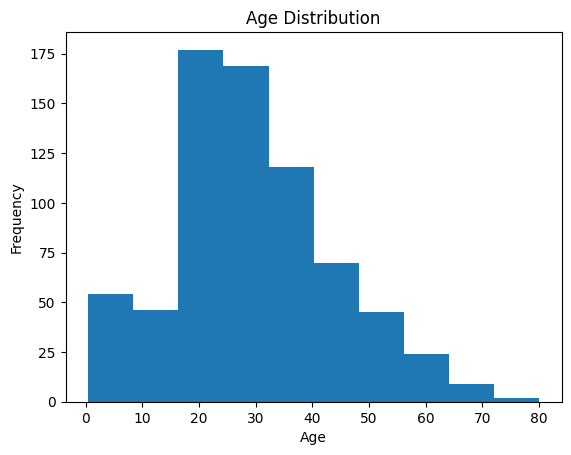

In [ ]:
plt.hist(df['age'])
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show

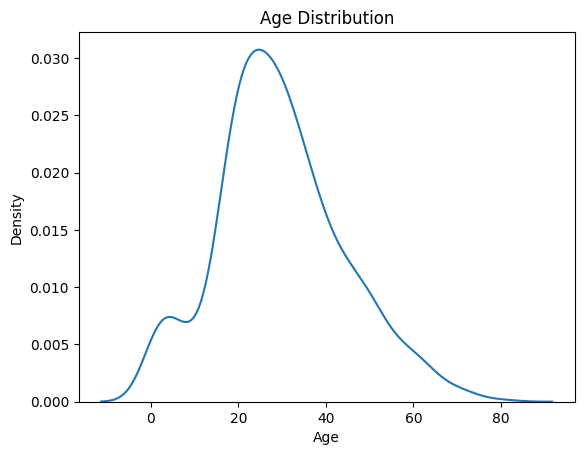

In [ ]:
sns.kdeplot(df['age'])
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age Distribution')
plt.show()

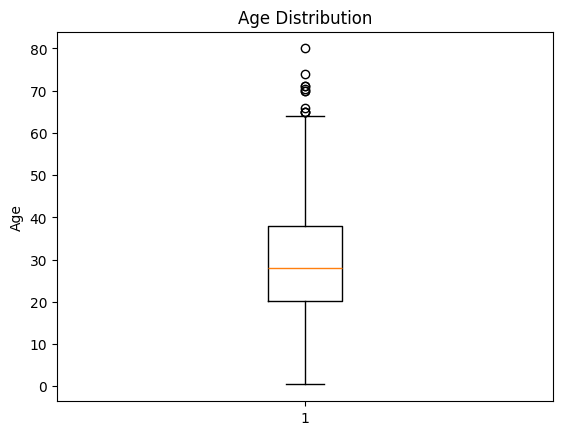

In [ ]:
plt.boxplot(df['age'])
plt.ylabel('Age')
plt.title('Age Distribution')
plt.show()

Task 4 — Correlation Heatmap

In [ ]:
corr2 = df[['survived', 'age', 'fare', 'pclass']].corr()
corr2

,survived,age,fare,pclass
survived,1.000000,-0.077221,0.268189,-0.359653
age,-0.077221,1.000000,0.096067,-0.369226
fare,0.268189,0.096067,1.000000,-0.554182
pclass,-0.359653,-0.369226,-0.554182,1.000000


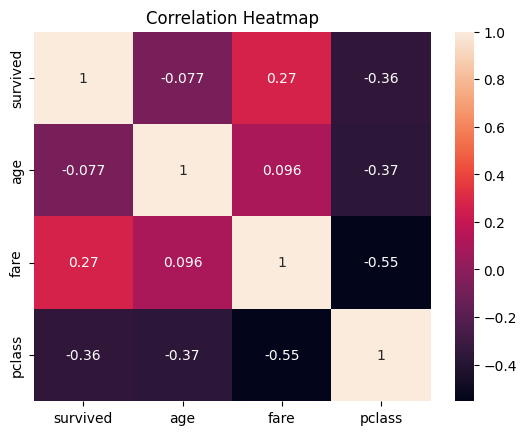

In [ ]:
sns.heatmap(corr2, annot=True)
plt.title('Correlation Heatmap')
plt.show()

#Question 3 — Machine Learning

Task 1 — Load and Pre-process

In [ ]:
df = pd.read_csv("/content/student_performance.csv")
df

,StudentID,Gender,Age,ParentEducation,StudyHoursPerWeek,AttendanceRate,InternetAccess,MidtermScore,FinalScore,Result
0,1001,Male,15,Secondary,10.6,39.8,Yes,23.2,31.5,0
1,1002,Male,18,Higher,9.6,71.2,No,44.9,40.4,0
2,1003,Male,18,Secondary,5.0,56.6,Yes,30.3,36.9,0
3,1004,Male,19,Secondary,23.5,79.3,Yes,53.0,62.9,1
4,1005,Male,21,Secondary,18.7,88.4,Yes,47.6,44.4,0
...,...,...,...,...,...,...,...,...,...,...
495,1496,Male,22,Secondary,31.0,78.5,No,54.5,55.0,1
496,1497,Male,21,Higher,14.0,34.2,No,34.7,18.9,0
497,1498,Female,16,Primary,22.1,NaN,Yes,45.5,49.7,0
498,1499,Male,19,Higher,1.7,64.8,No,31.7,32.4,0


In [ ]:
df.isnull().sum()

,0
StudentID,0
Gender,0
Age,0
ParentEducation,126
StudyHoursPerWeek,18
AttendanceRate,28
InternetAccess,0
MidtermScore,0
FinalScore,0
Result,0


In [ ]:
df['StudyHoursPerWeek'].fillna(df['StudyHoursPerWeek'].mean(), inplace=True)
df.isnull().sum()

/tmp/ipykernel_2851/1712838840.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['StudyHoursPerWeek'].fillna(df['StudyHoursPerWeek'].mean(), inplace=True)


,0
StudentID,0
Gender,0
Age,0
ParentEducation,126
StudyHoursPerWeek,0
AttendanceRate,28
InternetAccess,0
MidtermScore,0
FinalScore,0
Result,0


In [ ]:
df['AttendanceRate'].fillna(df['AttendanceRate'].mean(), inplace=True)
df.isnull().sum()

/tmp/ipykernel_2851/1993544575.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AttendanceRate'].fillna(df['AttendanceRate'].mean(), inplace=True)


,0
StudentID,0
Gender,0
Age,0
ParentEducation,126
StudyHoursPerWeek,0
AttendanceRate,0
InternetAccess,0
MidtermScore,0
FinalScore,0
Result,0


In [ ]:
df['ParentEducation'].fillna(df['ParentEducation'].mode()[0], inplace=True)
df.isnull().sum()

/tmp/ipykernel_2851/3823655898.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ParentEducation'].fillna(df['ParentEducation'].mode()[0], inplace=True)


,0
StudentID,0
Gender,0
Age,0
ParentEducation,0
StudyHoursPerWeek,0
AttendanceRate,0
InternetAccess,0
MidtermScore,0
FinalScore,0
Result,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['ParentEducation'] = le.fit_transform(df['ParentEducation'])
df['InternetAccess'] = le.fit_transform(df['InternetAccess'])
df

,StudentID,Gender,Age,ParentEducation,StudyHoursPerWeek,AttendanceRate,InternetAccess,MidtermScore,FinalScore,Result
0,1001,1,15,2,10.600000,39.800000,1,23.2,31.5,0
1,1002,1,18,0,9.600000,71.200000,0,44.9,40.4,0
2,1003,1,18,2,5.000000,56.600000,1,30.3,36.9,0
3,1004,1,19,2,23.500000,79.300000,1,53.0,62.9,1
4,1005,1,21,2,18.700000,88.400000,1,47.6,44.4,0
...,...,...,...,...,...,...,...,...,...,...
495,1496,1,22,2,31.000000,78.500000,0,54.5,55.0,1
496,1497,1,21,0,14.000000,34.200000,0,34.7,18.9,0
497,1498,0,16,1,22.100000,65.293644,1,45.5,49.7,0
498,1499,1,19,0,1.700000,64.800000,0,31.7,32.4,0


In [ ]:
df['Result'] = (df['FinalScore'] >= 50).astype(int)

df

,StudentID,Gender,Age,ParentEducation,StudyHoursPerWeek,AttendanceRate,InternetAccess,MidtermScore,FinalScore,Result
0,1001,1,15,2,10.600000,39.800000,1,23.2,31.5,0
1,1002,1,18,0,9.600000,71.200000,0,44.9,40.4,0
2,1003,1,18,2,5.000000,56.600000,1,30.3,36.9,0
3,1004,1,19,2,23.500000,79.300000,1,53.0,62.9,1
4,1005,1,21,2,18.700000,88.400000,1,47.6,44.4,0
...,...,...,...,...,...,...,...,...,...,...
495,1496,1,22,2,31.000000,78.500000,0,54.5,55.0,1
496,1497,1,21,0,14.000000,34.200000,0,34.7,18.9,0
497,1498,0,16,1,22.100000,65.293644,1,45.5,49.7,0
498,1499,1,19,0,1.700000,64.800000,0,31.7,32.4,0


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

In [ ]:
features = ['Gender', 'ParentEducation', 'StudyHoursPerWeek', 'AttendanceRate', 'InternetAccess']

X = df[features]
y = df['Result']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print(X_scaled)

[[ 9.49284301e-01  8.68279093e-01 -8.32541789e-01 -1.30136520e+00
   7.56522996e-01]
 [ 9.49284301e-01 -1.56387523e+00 -9.23618762e-01  3.01499702e-01
  -1.32183688e+00]
 [ 9.49284301e-01  8.68279093e-01 -1.34257284e+00 -4.43781432e-01
   7.56522996e-01]
 ...
 [-1.05342519e+00 -3.47798068e-01  2.14843399e-01 -7.25416569e-16
   7.56522996e-01]
 [ 9.49284301e-01 -1.56387523e+00 -1.64312685e+00 -2.51988774e-02
  -1.32183688e+00]
 [ 9.49284301e-01 -1.56387523e+00  0.00000000e+00  1.21523479e+00
  -1.32183688e+00]]


Task 2 — Train Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

len(X_train), len(X_test)

(400, 100)

In [ ]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Task 3 — Evaluate Model

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)

In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_lr = precision_score(y_test, y_pred_lr)
precision_dt = precision_score(y_test, y_pred_dt)

recall_lr = recall_score(y_test, y_pred_lr)
recall_dt = recall_score(y_test, y_pred_dt)


print("Logistic Regression Accuracy:", accuracy_lr)
print("Decision Tree Accuracy:", accuracy_dt)
print("Logistic Regression Precision:", precision_lr)
print("Decision Tree Precision:", precision_dt)
print("Logistic Regression Recall:", recall_lr)
print("Decision Tree Recall:", recall_dt)

Logistic Regression Accuracy: 0.84
Decision Tree Accuracy: 0.71
Logistic Regression Precision: 0.8285714285714286
Decision Tree Precision: 0.6190476190476191
Logistic Regression Recall: 0.7435897435897436
Decision Tree Recall: 0.6666666666666666


In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)
cm

array([[55,  6],
       [10, 29]])

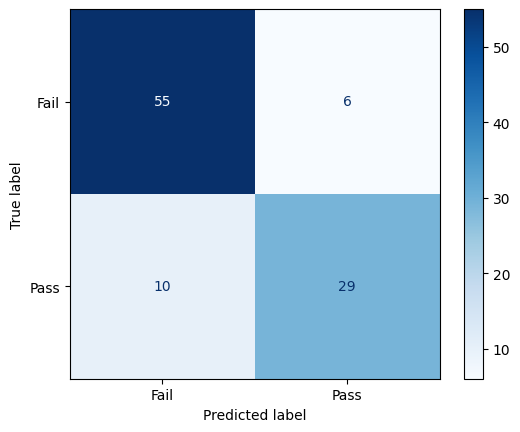

In [ ]:
disp = ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass'])
disp.plot(cmap='Blues')
plt.show()

Task 4 — Save and Reload Model

In [ ]:
import pickle

In [ ]:
with open('model.pkl', 'wb') as f:
    pickle.dump(lr, f)

In [ ]:
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)